In [1]:
import numpy as np
import matplotlib.pyplot as plt
import Optimal_transport as ot

cm_to_inch=0.393701

In [2]:
def gauss(x,mu,sigma):
    
    return np.exp(-1*(x-mu)**2/(2*sigma**2))/(sigma*np.sqrt(2*np.pi))

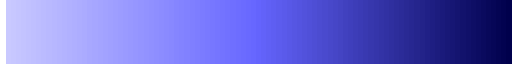

In [3]:
vals_red=np.linspace(0.8,0.0,100)
vals_blue=np.ones(100)-np.linspace(-0.7,0.7,100)
vals_green=np.linspace(0.8,0.0,100)

vals=np.vstack((vals_red,vals_green,vals_blue))
vals[0,0]=1
vals[1,0]=1

vals[vals>1]=1

from matplotlib.colors import ListedColormap
newcmp = ListedColormap(vals.T)
newcmp

## Plan de transport

In [4]:
def trapeze(x,y):
    """
    Compute the integral of a function using the trapeze method
    Parameters
    ----------
    x: List of xs
    y: List of ys

    Returns
    -------
    float, value of the integral
    """
    return sum((x[1:]-x[:-1])*(y[:-1]+y[1:])/2)

def cumul(P):
    """
    Compute the cumulative function of a probabilistic distribution

    Parameters
    ----------

    P : List that contains the Density probability

    Returns
    -------
    res : List that contains the cumulative distribution
    """
    res=np.zeros(len(P))
    for i in range(len(res)):
        if P[i]<0:
            print('Valeur négative rencontrée')
        res[i]=sum(P[:i+1])
    return res

def cost_matrix(ta,tb,how='L2'):
    """
    Compute the Euclidian cost matrix between two Times list

    Parameters
    ----------
    ta: List, contains the times steps for the first time series
    tb: List, contains the times steps for the second time series
    how: Method to compute the distance between two time steps

    Returns
    -------
    Numpy array, cost matrix
    """

    Ta,Tb=np.meshgrid(ta,tb)

    return (Ta-Tb)**2


def plan_1D(a,b,tol=1e-3):
    CDFa=cumul(a)
    CDFb=cumul(b)
    if abs(CDFa[-1]-CDFb[-1])/CDFa[-1]>tol:
        raise Exception(
            'The total masses are too different to use the 1D optimal transport here, use unbalanced optimal transport instead')
    
    tm=max(CDFa[-1],CDFb[-1])
    
    CDFa*=tm/CDFa[-1]
    CDFb*=tm/CDFb[-1]
    a_bis=np.array([CDFa[0],*np.diff(CDFa)])
    b_bis=np.array([CDFb[0],*np.diff(CDFb)])
    ny,nx=len(a),len(b)
    res=np.zeros((ny,nx))
    reste=0
    for i in range(ny):
        mask=np.argwhere(CDFb<=CDFa[i]).T[0]
        if len(mask)==0:
            res[i,0]+=a_bis[i]
            reste+=a_bis[i]
        if len(mask)>0:
            if len(mask)==len(b):
                res[i,-1]+=a_bis[i]
            else:
                res[i,mask]+=b_bis[mask]
                reste+=a_bis[i]-sum(b_bis[mask])
                res[i,mask[-1]+1]+=reste
                b_bis[mask]-=b_bis[mask]
                b_bis[mask[-1]+1]-=reste
                reste=0
    return res


def Sinkhorn(a,b,C,eps=1e-2,stopTrh=1e-10,NumIterMax=10000,cost=True): 
        """
        Compute the Sinkhorn algorithm for optimal transport

        Parameters
        ----------
        a: List, First distribution
        b: List, Second distribution
        C: Matrix, Cost matrix associated to the two time series
        eps: float, entropic regularisation parameter
        stopTrh: float, Treshold at which the progress is too small, and therefore where we have reached the convergence
        NumIterMax: int, In case of no convergence, maximum number of iteration
        cost: if True, return the cost, if False, return 

        """
        dim_a=len(a)
        dim_b=len(b)
        niter=int(-np.log(eps)/np.log(2))
        eps_i=1
        K=np.exp(-C/eps_i)
        v=np.ones(dim_b)
        if np.any(K@v == 0):
            print('probleme',np.max(C))
        u=a/(K@v)
        for j in range(niter):
            K=np.exp(-C/eps_i)

            P=u[:, None] * K * v[None, :]
            for i in range(NumIterMax):
                if (np.any(K.T@u == 0) or (np.any(K@v == 0))):
                    # we have reached the machine precision
                    # come back to previous solution and quit loop
                    break
                u=a/(K@v)
                v=b/(K.T@u)
                P2=u[:, None] * K * v[None, :]

                if np.sum(abs(P2-P))<stopTrh:
                    break
                P=P2

            eps_i/=2

        K=np.exp(-C/eps)
        P=u[:, None] * K * v[None, :]
        for i in range(NumIterMax):
            if (np.any(K.T@u == 0) or (np.any(K@v == 0))):
                # we have reached the machine precision
                # come back to previous solution and quit loop
                break

            u=a/(K@v)
            v=b/(K.T@u)
            P2=u[:, None] * K * v[None, :]

            if np.sum(abs(P2-P))<stopTrh:
                break
            P=P2

        if cost:
            return np.sum(P*C)
        else:
            return P


In [5]:
X=np.linspace(0,15,150)
Y=np.zeros(150)

X2=np.linspace(0,15,150)
Y2=np.zeros(150)

Y+=gauss(X,4,1)*2
Y+=gauss(X,10,1)*0.7

Y2+=gauss(X,3,1)*1.7
Y2+=gauss(X,11,1)*1

Y/=np.sum(Y)
Y2/=np.sum(Y2)

X/=np.max(X)

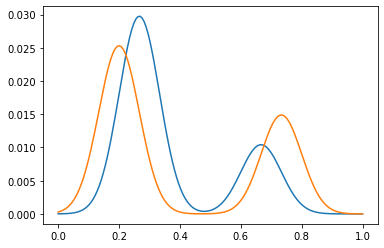

In [6]:
plt.figure()
plt.plot(X,Y)
plt.plot(X,Y2)

In [7]:
plan=plan_1D(Y,Y2)
plan[plan==0]=np.nan

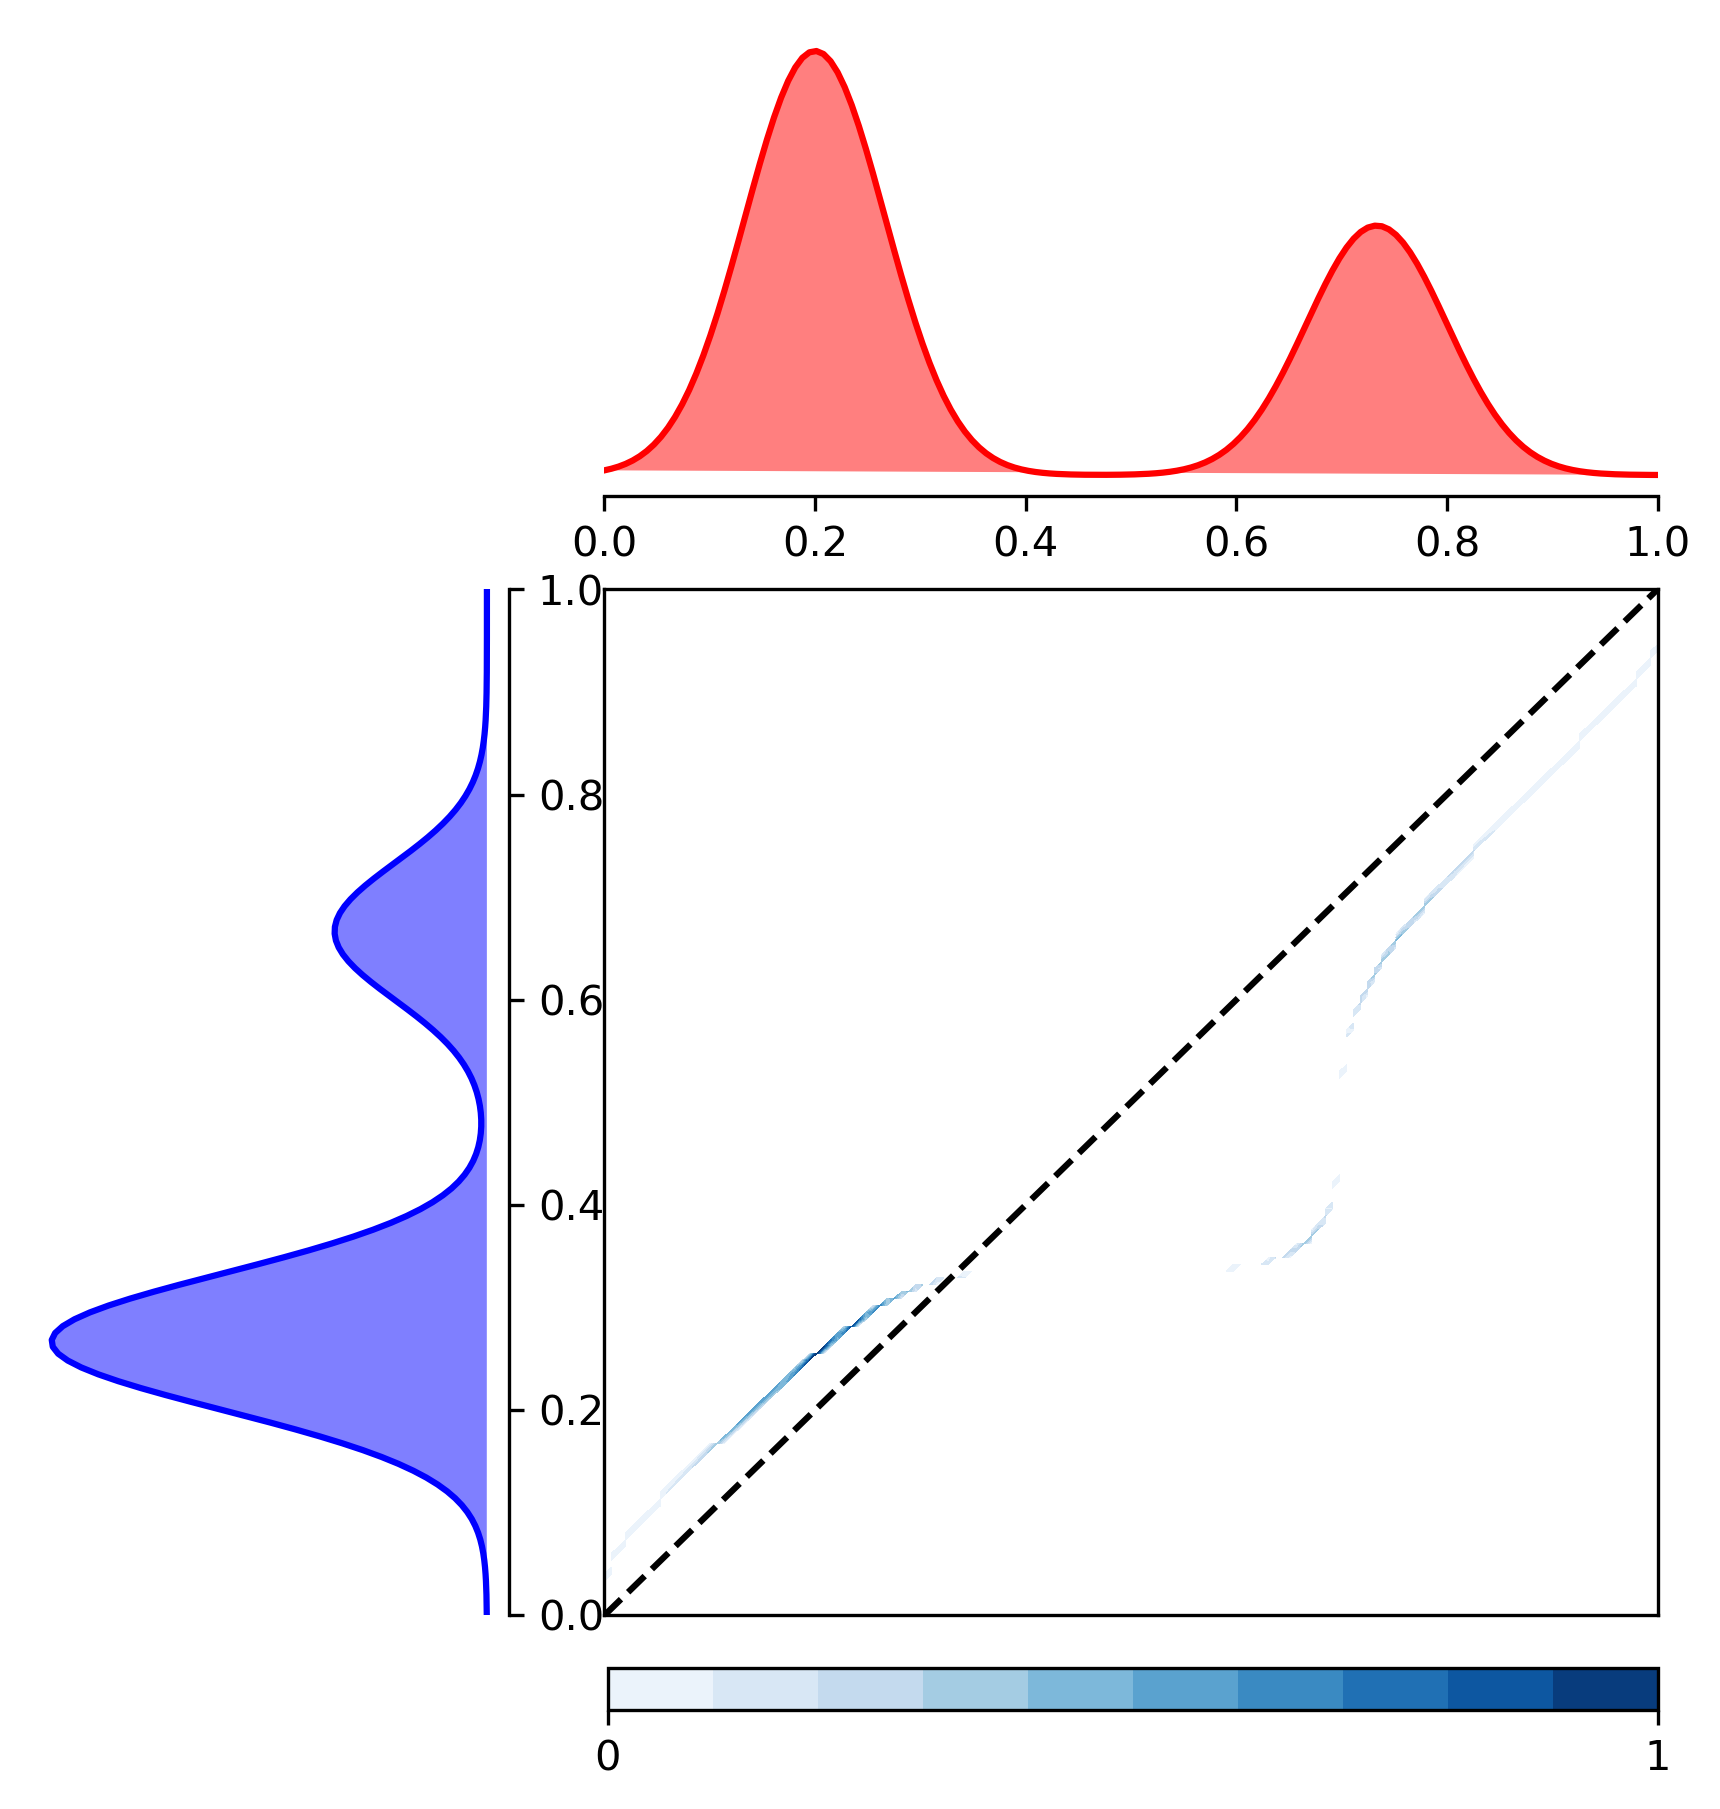

In [9]:
from matplotlib import gridspec
from matplotlib import cm
from matplotlib.colors import LightSource

fig=plt.figure(figsize=(7,7),dpi=300)



gs = gridspec.GridSpec(3, 3)

ax1 = plt.subplot(gs[0, 1:])
plt.plot(X, Y2, 'r', label='Target distribution')
plt.fill(X, Y2, 'r', label='Target distribution',alpha=0.5)
plt.yticks(())
for pos in ['top', 'left','right']:
    plt.gca().spines[pos].set_visible(False)
    




ax2 = plt.subplot(gs[1:, 0])
plt.plot(Y,X, 'b', label='Source distribution')
plt.fill(Y,X, 'b', label='Source distribution',alpha=0.5)
plt.gca().invert_xaxis()
plt.xticks(())
for pos in ['top','bottom', 'left']:
    plt.gca().spines[pos].set_visible(False)

ax2.yaxis.tick_right()    


ax3=plt.subplot(gs[1:, 1:], sharex=ax1, sharey=ax2)
cf=plt.contourf(X,X,plan/np.nanmax(plan),cmap='Blues',vmin=-0.01,levels=10)
plt.plot([0,1],[0,1],'--',color='black')
plt.tick_params(left = False, right = False , labelleft = False ,
            labelbottom = False, bottom = False)



cax = fig.add_axes([0.4, 0.08, .5,0.02])
cbar=plt.colorbar(cf,cax=cax, orientation='horizontal',ticks=[0, 1])



In [10]:
Ymat,Y2mat=np.meshgrid(Y,Y2,indexing='ij')
plan2=Ymat*Y2mat
plan2[plan2==0]=np.nan

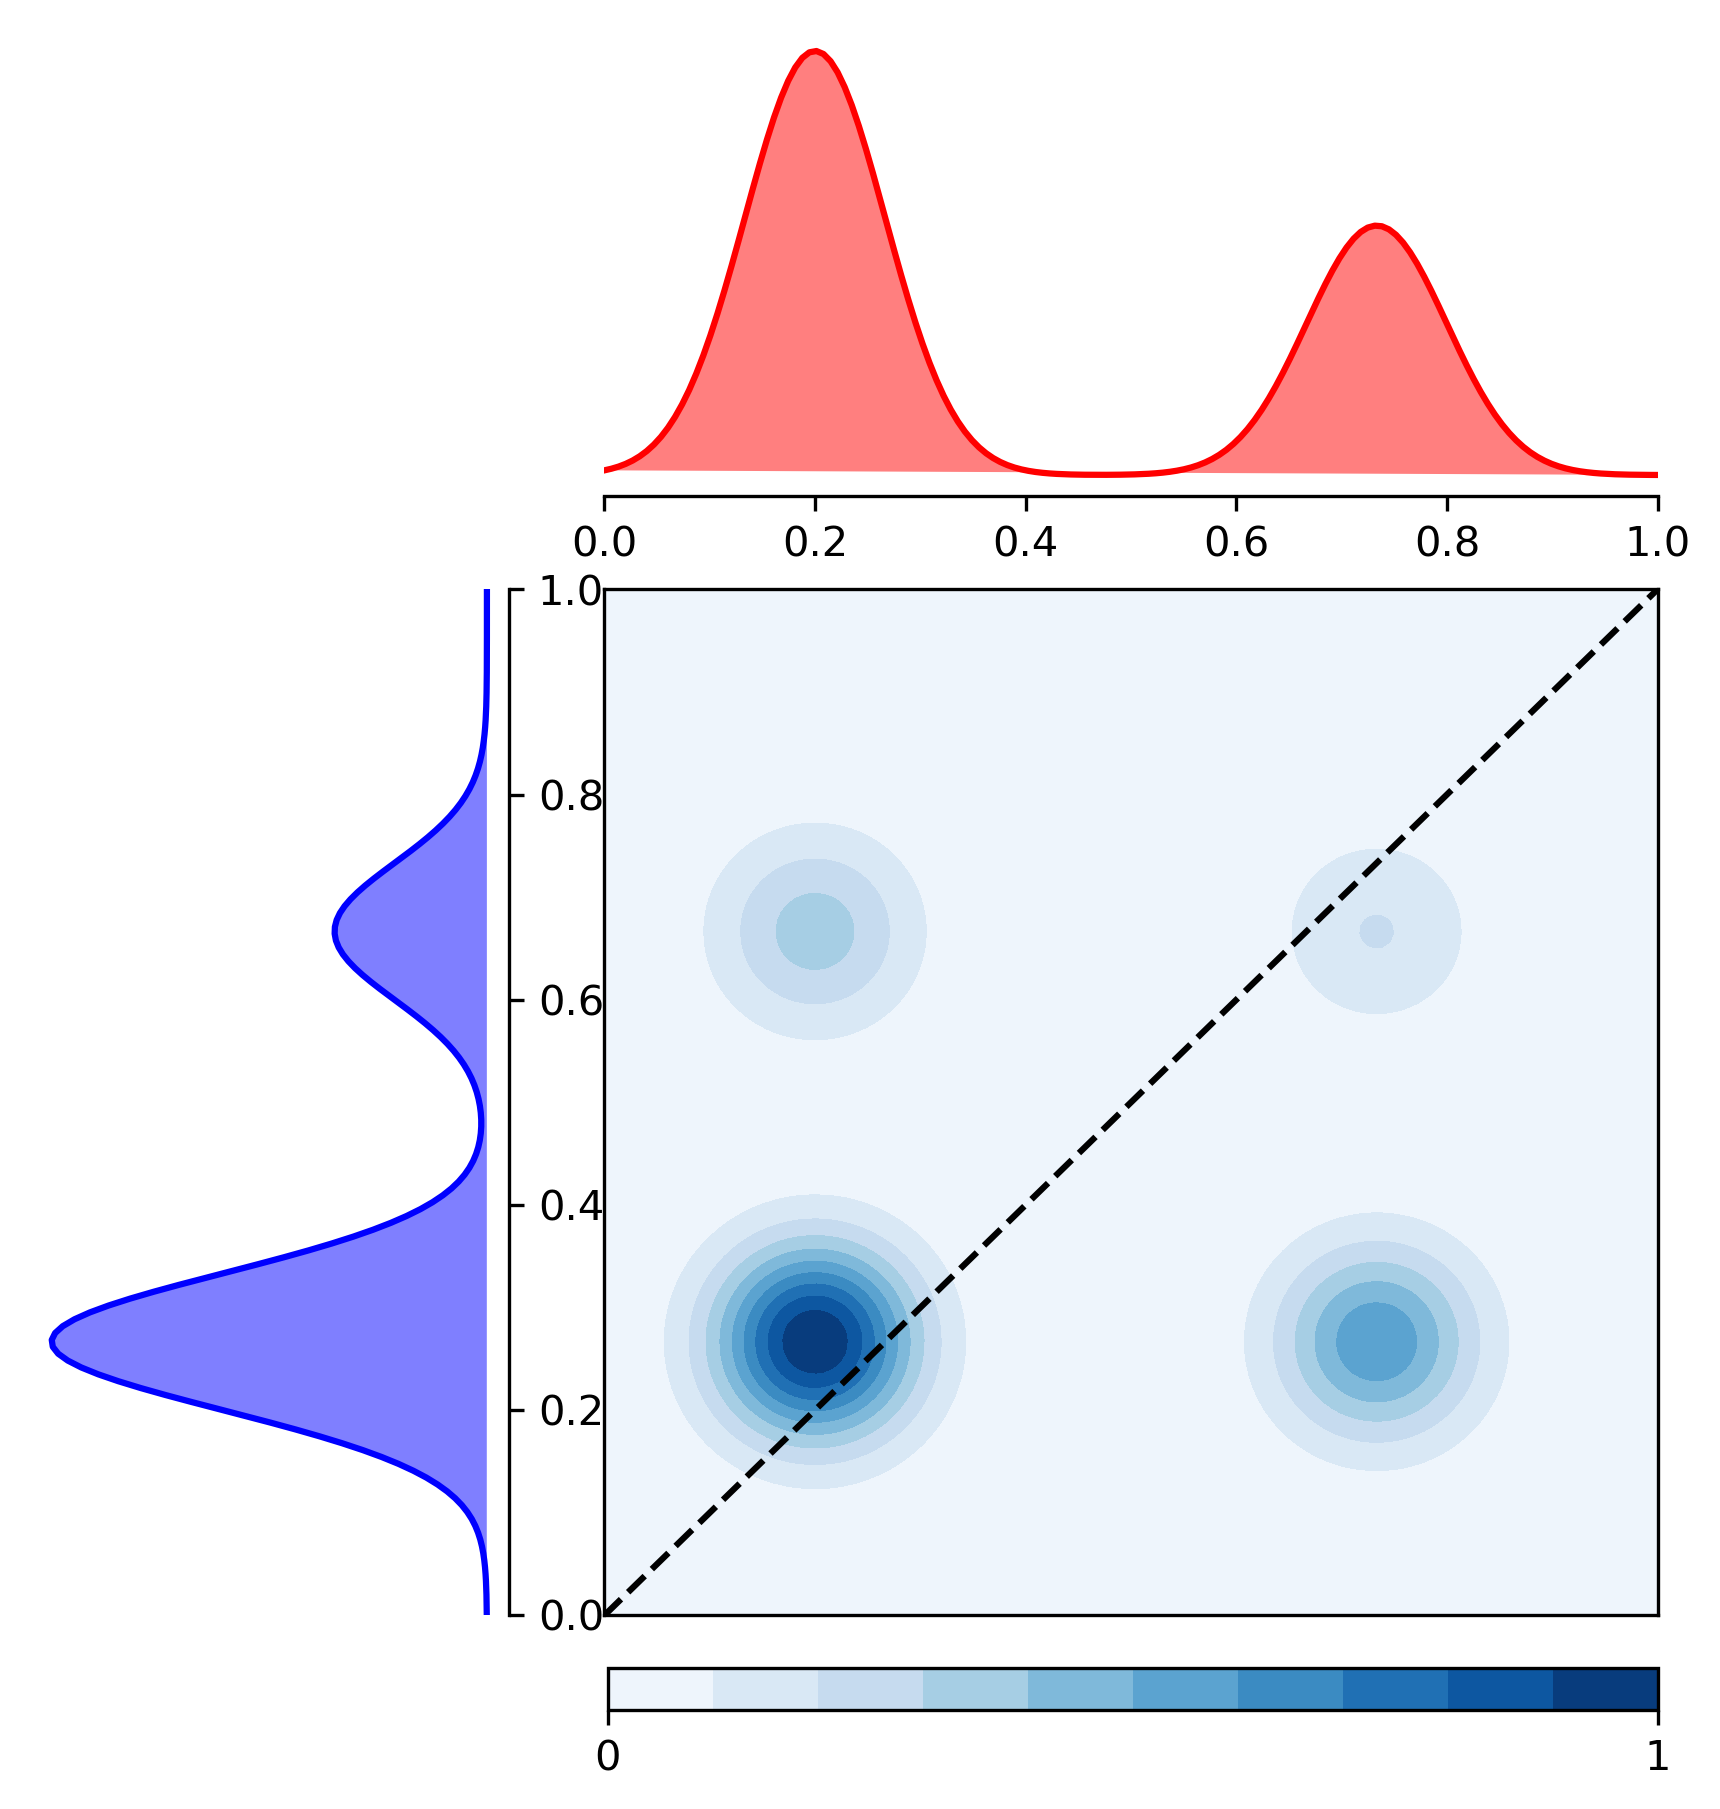

In [11]:
from matplotlib import gridspec
from matplotlib import cm
from matplotlib.colors import LightSource


fig=plt.figure(figsize=(7,7),dpi=300)



gs = gridspec.GridSpec(3, 3)

ax1 = plt.subplot(gs[0, 1:])
plt.plot(X, Y2, 'r', label='Target distribution')
plt.fill(X, Y2, 'r', label='Target distribution',alpha=0.5)
plt.yticks(())
for pos in ['top', 'left','right']:
    plt.gca().spines[pos].set_visible(False)


ax2 = plt.subplot(gs[1:, 0])
plt.plot(Y,X, 'b', label='Source distribution')
plt.fill(Y,X, 'b', label='Source distribution',alpha=0.5)
plt.gca().invert_xaxis()
plt.xticks(())
for pos in ['top','bottom', 'left']:
    plt.gca().spines[pos].set_visible(False)

ax2.yaxis.tick_right()    


ax3=plt.subplot(gs[1:, 1:], sharex=ax1, sharey=ax2)
cf=plt.contourf(X,X,plan2/np.nanmax(plan2),cmap='Blues',levels=10)
plt.plot([0,1],[0,1],'--',color='black')
plt.tick_params(left = False, right = False , labelleft = False ,
            labelbottom = False, bottom = False)

cax = fig.add_axes([0.4, 0.08, .5,0.02])
cbar=plt.colorbar(cf,cax=cax, orientation='horizontal',ticks=[0, 1])




In [12]:
plan3=Sinkhorn(Y/np.max(Y),Y2/np.max(Y),cost_matrix(X,X),cost=False,eps=1e-3)
plan3[plan3==0]=np.nan

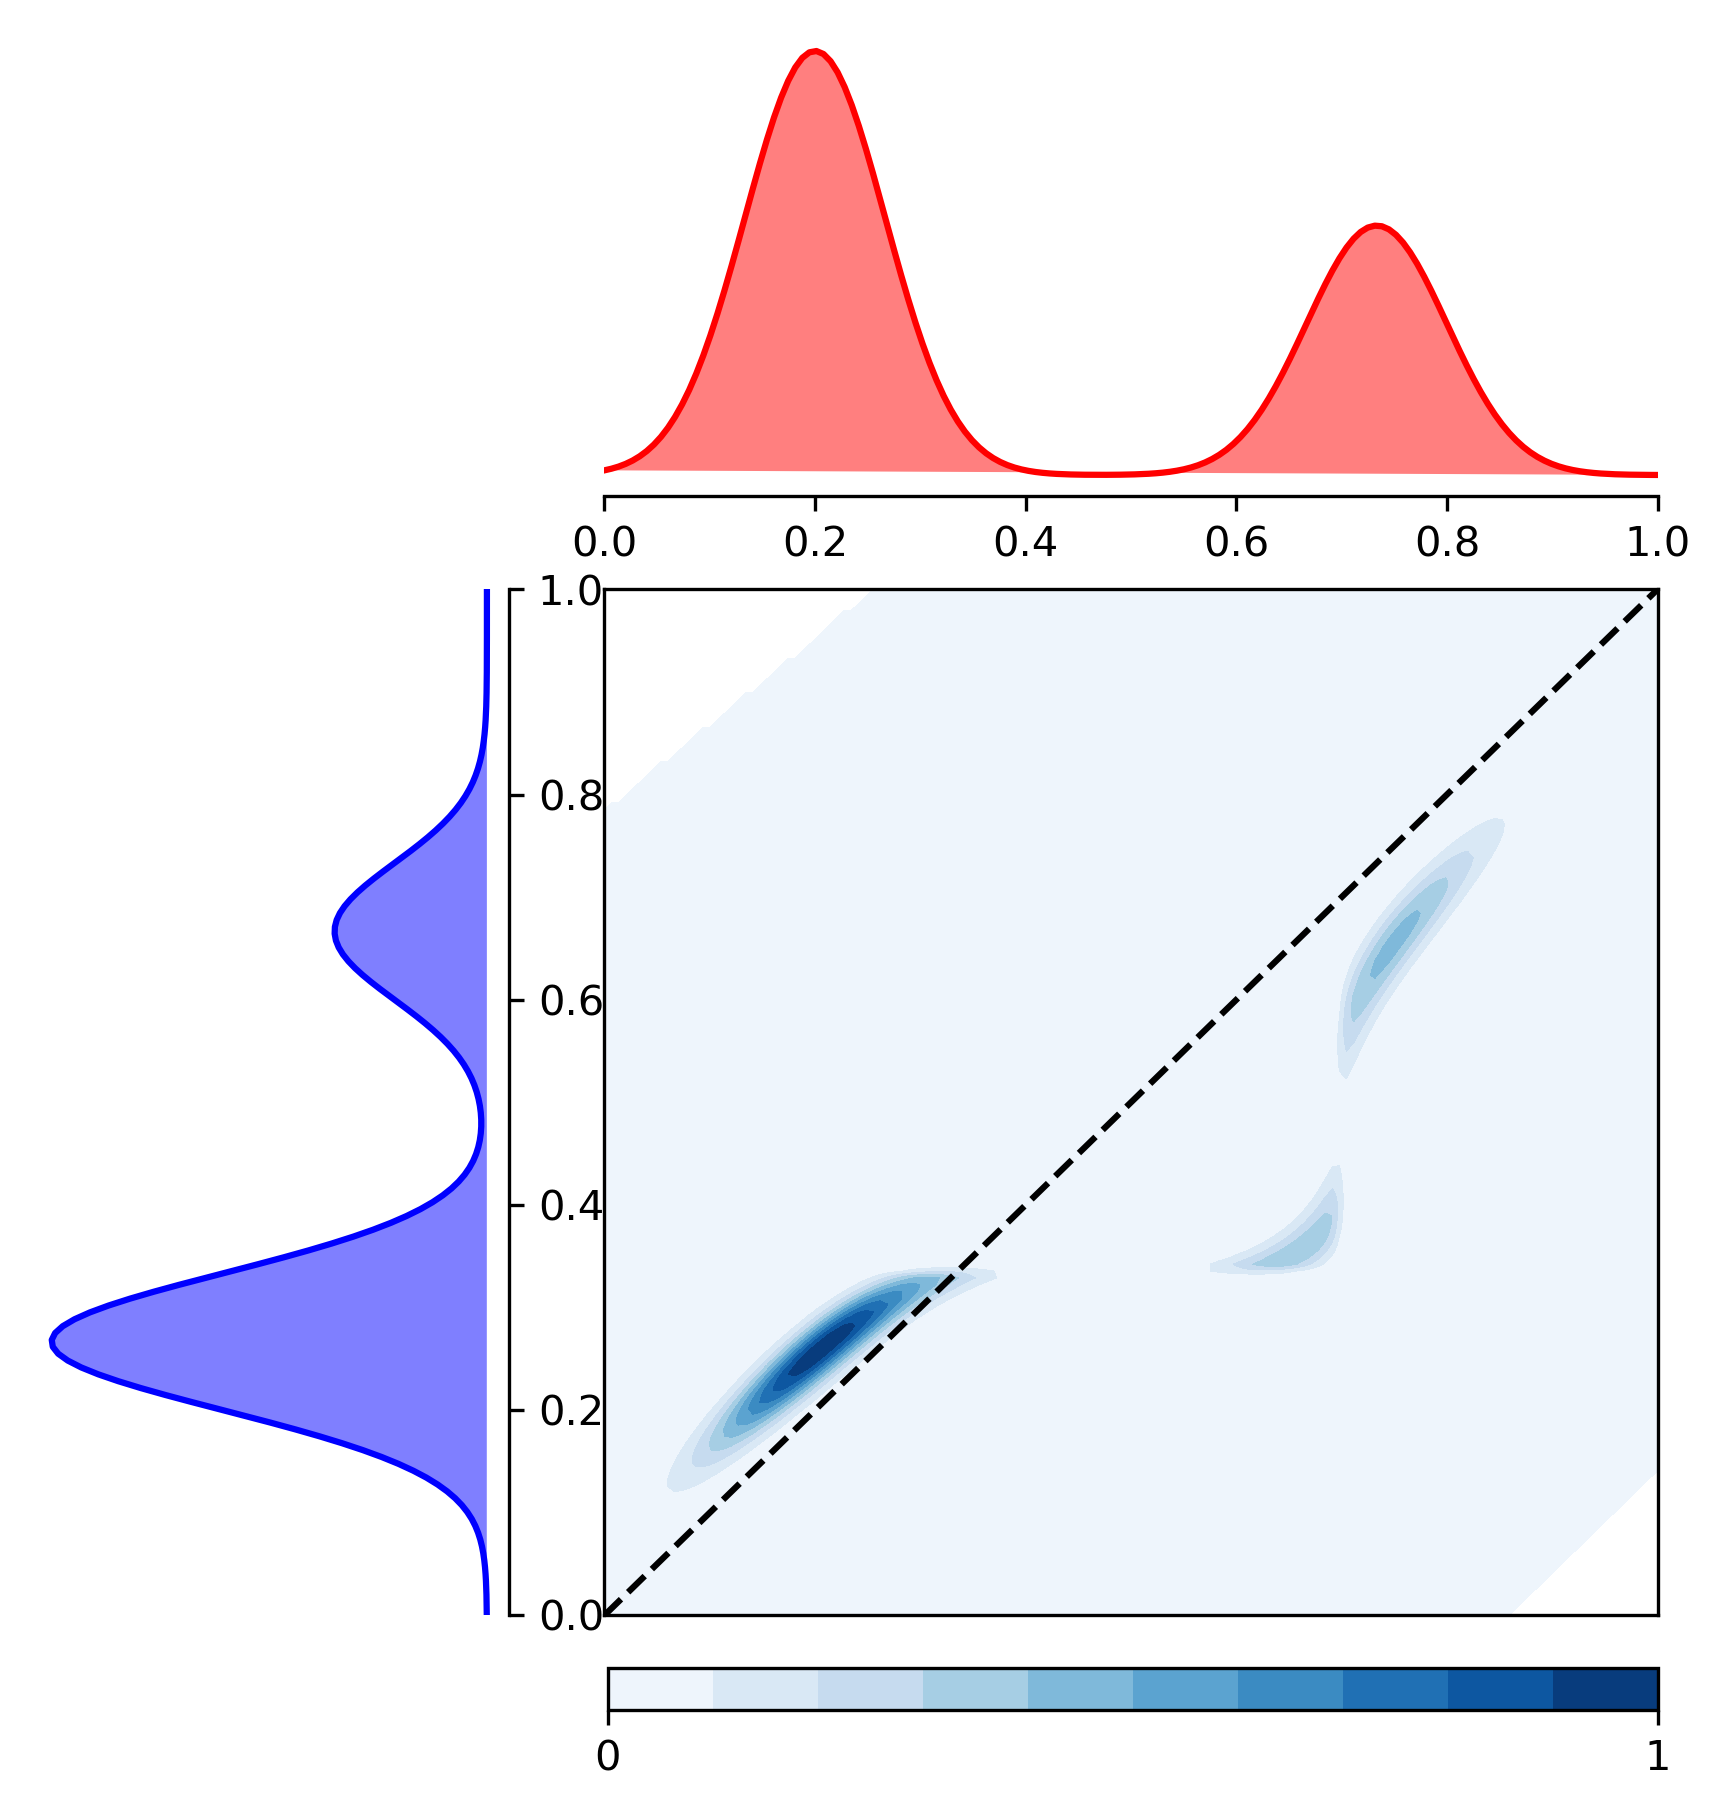

In [13]:
from matplotlib import gridspec
from matplotlib import cm
from matplotlib.colors import LightSource


fig=plt.figure(figsize=(7,7),dpi=300)



gs = gridspec.GridSpec(3, 3)

ax1 = plt.subplot(gs[0, 1:])
plt.plot(X, Y2, 'r', label='Target distribution')
plt.fill(X, Y2, 'r', label='Target distribution',alpha=0.5)
plt.yticks(())
for pos in ['top', 'left','right']:
    plt.gca().spines[pos].set_visible(False)


ax2 = plt.subplot(gs[1:, 0])
plt.plot(Y,X, 'b', label='Source distribution')
plt.fill(Y,X, 'b', label='Source distribution',alpha=0.5)
plt.gca().invert_xaxis()
plt.xticks(())
for pos in ['top','bottom', 'left']:
    plt.gca().spines[pos].set_visible(False)

ax2.yaxis.tick_right()    


ax3=plt.subplot(gs[1:, 1:], sharex=ax1, sharey=ax2)
cf=plt.contourf(X,X,plan3/np.nanmax(plan3),cmap='Blues',levels=10)
plt.plot([0,1],[0,1],'--',color='black')
plt.tick_params(left = False, right = False , labelleft = False ,
            labelbottom = False, bottom = False)

cax = fig.add_axes([0.4, 0.08, .5,0.02])
cbar=plt.colorbar(cf,cax=cax, orientation='horizontal',ticks=[0, 1])



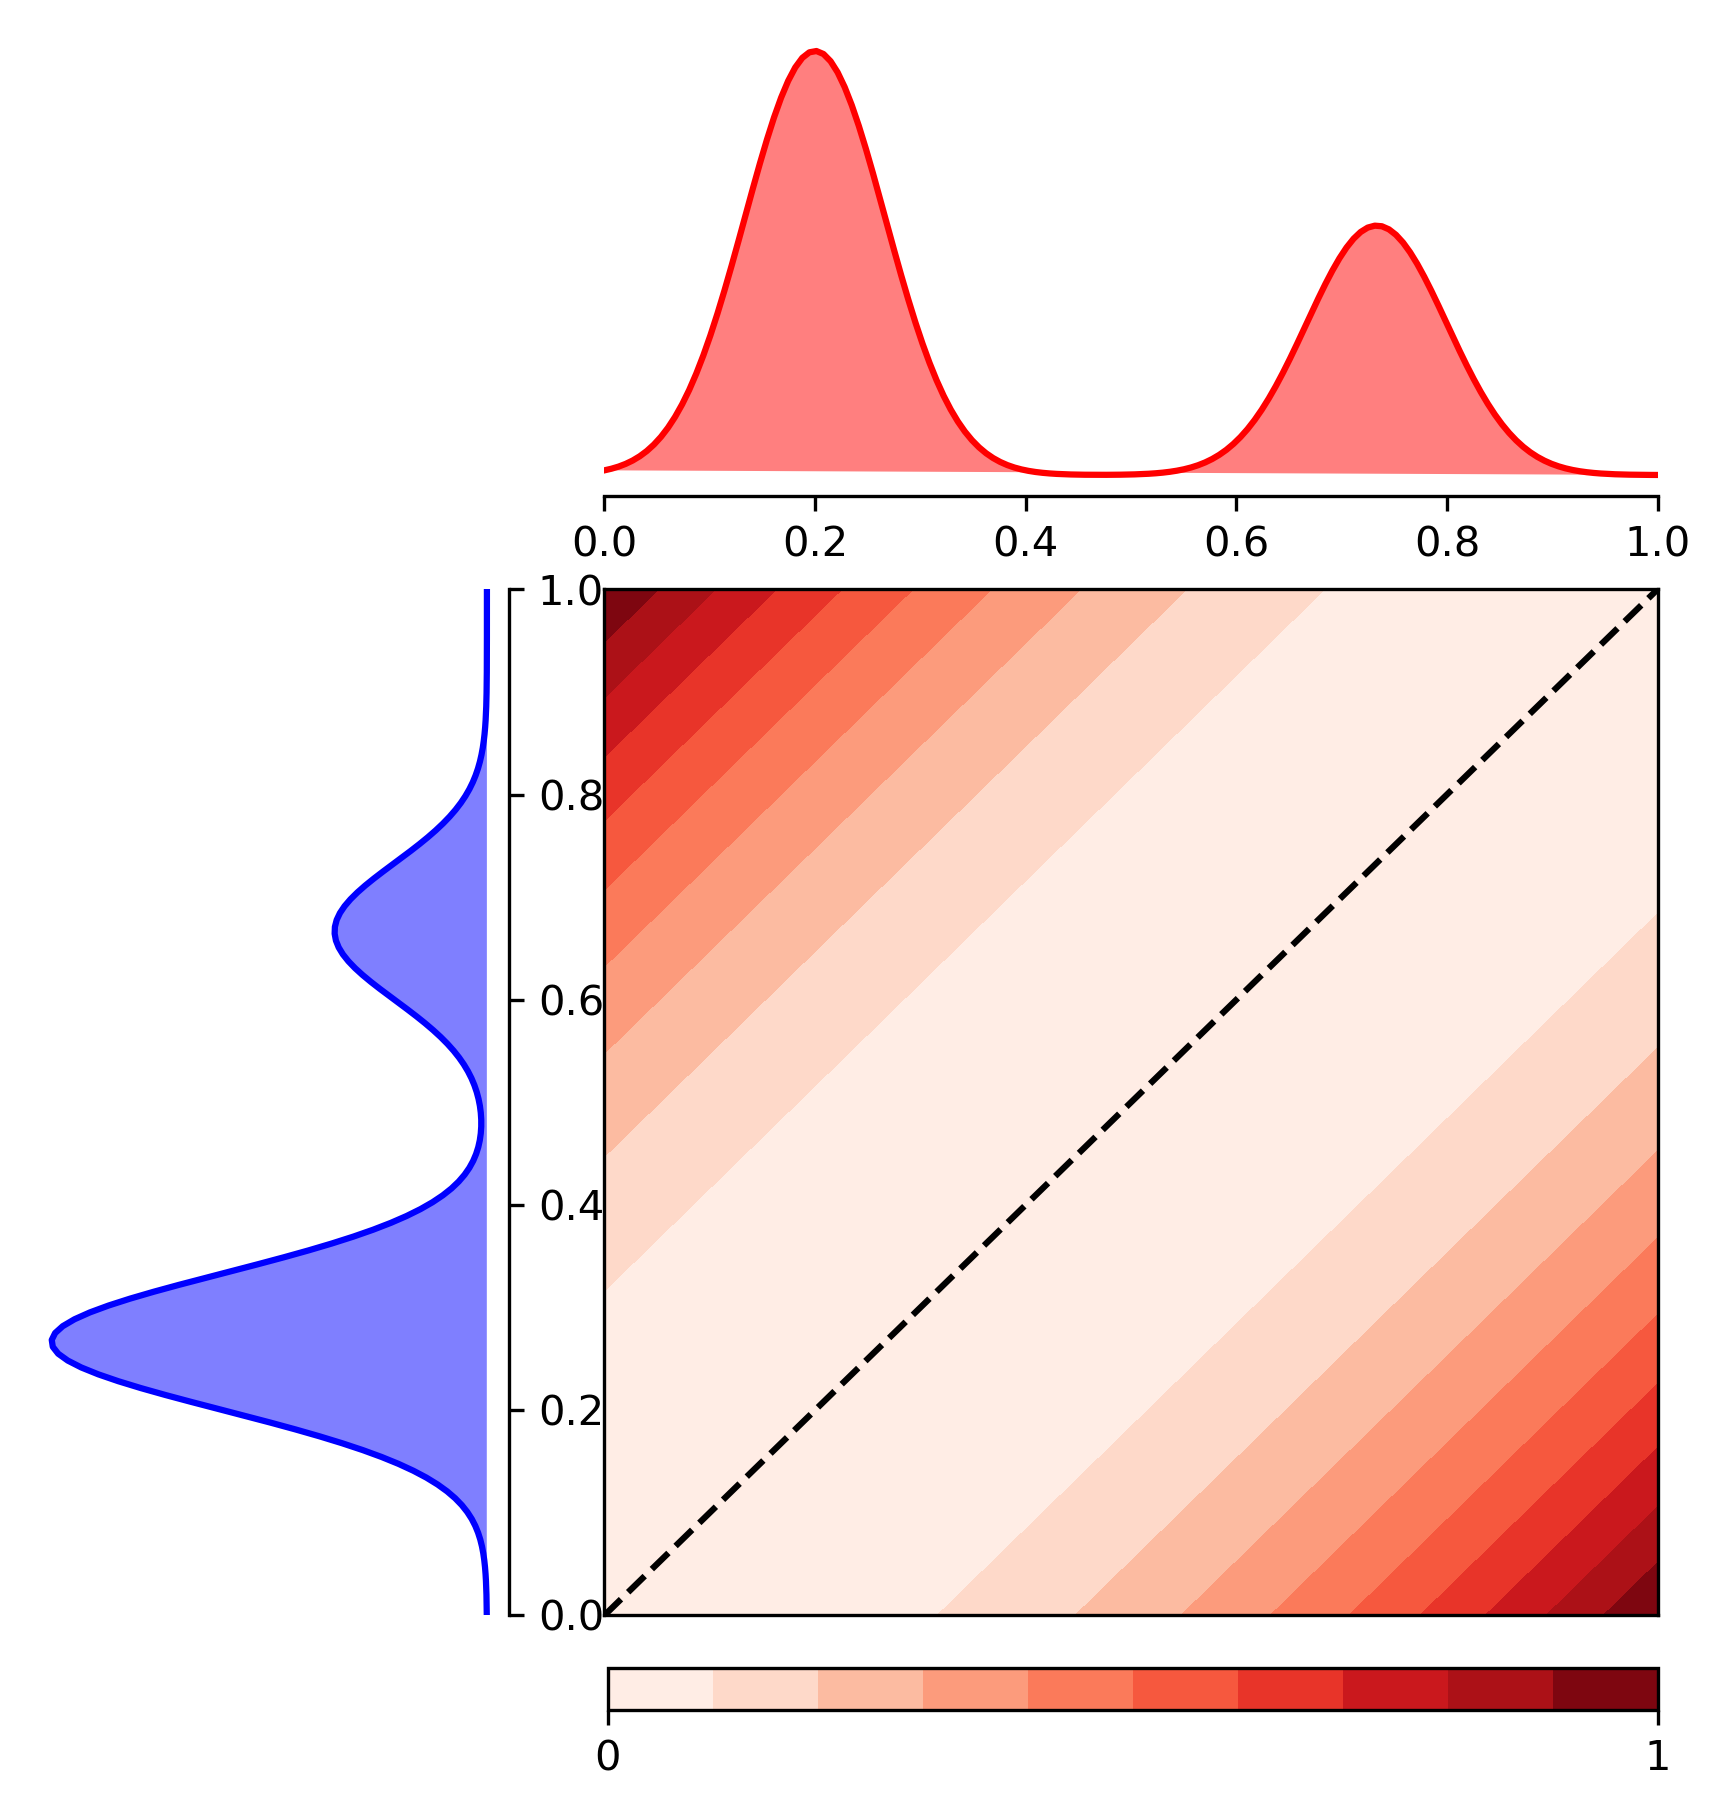

In [14]:
from matplotlib import gridspec
from matplotlib import cm
from matplotlib.colors import LightSource


fig=plt.figure(figsize=(7,7),dpi=300)



gs = gridspec.GridSpec(3, 3)

ax1 = plt.subplot(gs[0, 1:])
plt.plot(X, Y2, 'r', label='Target distribution')
plt.fill(X, Y2, 'r', label='Target distribution',alpha=0.5)
plt.yticks(())
for pos in ['top', 'left','right']:
    plt.gca().spines[pos].set_visible(False)


ax2 = plt.subplot(gs[1:, 0])
plt.plot(Y,X, 'b', label='Source distribution')
plt.fill(Y,X, 'b', label='Source distribution',alpha=0.5)
plt.gca().invert_xaxis()
plt.xticks(())
for pos in ['top','bottom', 'left']:
    plt.gca().spines[pos].set_visible(False)

ax2.yaxis.tick_right()    


ax3=plt.subplot(gs[1:, 1:], sharex=ax1, sharey=ax2)
cf=plt.contourf(X,X,cost_matrix(X,X),cmap='Reds',levels=10)
plt.plot([0,1],[0,1],'--',color='black')
plt.tick_params(left = False, right = False , labelleft = False ,
            labelbottom = False, bottom = False)


cax = fig.add_axes([0.4, 0.08, .5,0.02])
cbar=plt.colorbar(cf,cax=cax, orientation='horizontal',ticks=[0, 1])

